<a href="https://colab.research.google.com/github/Amr-boot/Amr-boot/blob/master/Test_project_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Shape of x_train: {x_train.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of x_train: (60000, 28, 28)


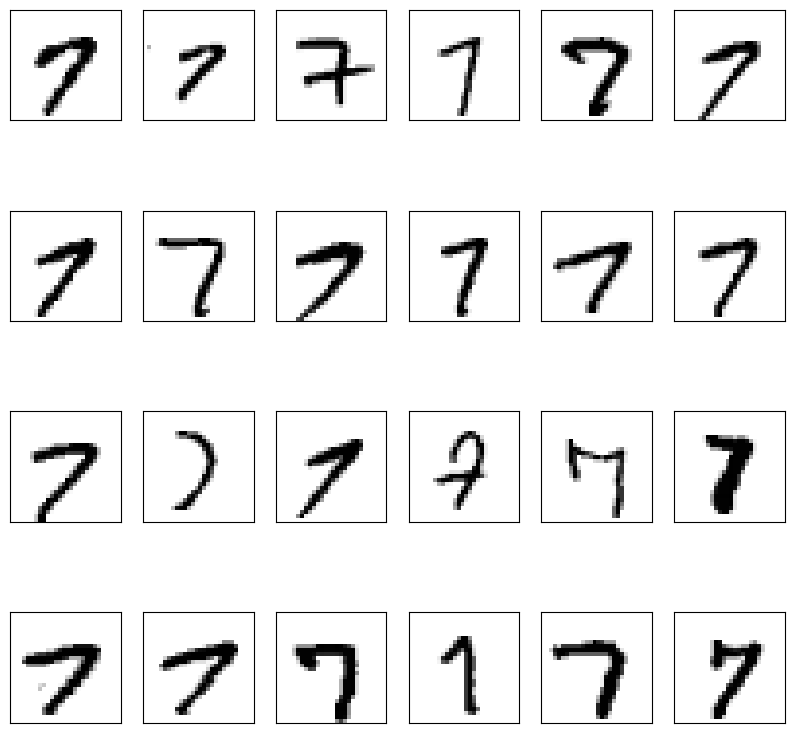

In [6]:
import matplotlib.pyplot as plt
max_4 = 24
list_photo = []
for i in range(len(y_train)):
  if y_train[i] == 7:
    list_photo.append(x_train[i])
  if len(list_photo) == max_4:
    break
plt.figure(figsize=(10, 10))
for i in range(max_4):
  plt.subplot(4, 6, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(list_photo[i], cmap=plt.cm.binary)
plt.show()





In [24]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.regularizers import l2
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
# Fixed: Wrap the float in l2()
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Capture the history object here, updated to 10 epochs
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8316 - loss: 1.4772 - val_accuracy: 0.9463 - val_loss: 0.5376
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9230 - loss: 0.5840 - val_accuracy: 0.9613 - val_loss: 0.4059
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9377 - loss: 0.4591 - val_accuracy: 0.9632 - val_loss: 0.3359
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9449 - loss: 0.3851 - val_accuracy: 0.9683 - val_loss: 0.2763
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9473 - loss: 0.3544 - val_accuracy: 0.9693 - val_loss: 0.2694
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9484 - loss: 0.3372 - val_accuracy: 0.9725 - val_loss: 0.2558
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9495 - loss: 0.3346 - val_accuracy: 0.9657 - val_loss: 0.2788
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9532 -

In [25]:
model_loss, model_acc = model.evaluate(x_test, y_test)
print(f"Model Loss: {model_loss}")
print(f"Model Accuracy: {model_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9633 - loss: 0.2643
Model Loss: 0.2642517685890198
Model Accuracy: 0.9632999897003174


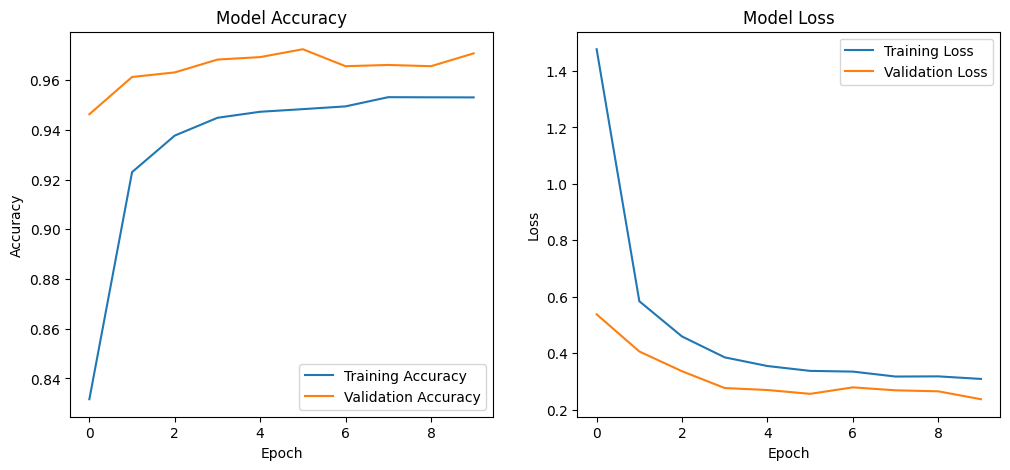

In [26]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()